# Cyberattack Classification

## Data Description

#### **a. Nama Dataset dan Sumbernya**  
- **Nama Dataset**: *Synthetic Social Media Messages for Early Cyberattack Detection on Blockchain*  
- **Sumber Dataset**: [Hugging Face – dn-institute/cyberattack-blockchain-synth](https://huggingface.co/datasets/dn-institute/cyberattack-blockchain-synth)  
- **Publikasi Terkait**:  
  *ELTEX: A Framework for Domain-Driven Synthetic Data Generation*  
  [arXiv:2503.15055v1](https://arxiv.org/html/2503.15055v1)

---

#### **b. Jumlah Data**  
- **Jumlah Sampel (Entitas)**: 11.465 pesan  
- **Jumlah Fitur**: 3 kolom (termasuk label)  
- **Label Target**:  
  - **Kolom**: `topic`  
  - **Jumlah Kelas**: 2 kelas  
  - **Deskripsi Kelas**:  
    - `cyberattack`: Pesan mengandung indikasi serangan siber  
    - `general`: Pesan umum, tidak terkait serangan siber

---

#### **c. Format dan Struktur Data**  
- **Format File**: CSV  
- **Struktur Kolom**:  
  - `message_id`: ID unik untuk setiap pesan  
  - `topic`: Label klasifikasi biner (`cyberattack` atau `general`)  
  - `content`: Teks dari pesan media sosial (synthetic)

## Import Library

In [1]:
%pip install hf_xet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 MB 28.8 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Seeding
SEED = 42
np.random.seed(SEED)

# Sklearn Modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder

# Sentence Transformers for Embedding
from sentence_transformers import SentenceTransformer

# Sklearn Pipeline
from sklearn.pipeline import Pipeline

print("=== Modules Loaded ===")

2025-05-01 08:01:44.484285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746086504.697671      69 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746086504.763296      69 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


=== Modules Loaded ===


## Data Loading

In [3]:
raw_df = pd.read_csv("hf://datasets/dn-institute/cyberattack-blockchain-synth/data/synth-cyberattack-blockchain.csv")
raw_df.head()

,message_id,topic,content
0,77ea8b97fbfc-0000,cyberattack,Just noticed a huge spike in transaction fees ...
1,77ea8b97fbfc-0001,cyberattack,Strange confirmation delays on DeltaBlock – tr...
2,77ea8b97fbfc-0002,cyberattack,Watch out! Dormant wallets on LambdaCoin have ...
3,77ea8b97fbfc-0003,cyberattack,Massive price drop on OmegaExchange in just mi...
4,77ea8b97fbfc-0004,cyberattack,ThetaToken’s mining difficulty has unexpectedl...


## Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Melihat Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11465 entries, 0 to 11464
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   message_id  11465 non-null  object
 1   topic       11465 non-null  object
 2   content     11465 non-null  object
dtypes: object(3)
memory usage: 268.8+ KB


Dari hasil tersebut terlihat bahwa tidak terdapat kolom yang memiliki nilai hilang (missing value). Setiap kolom sudah memiliki tipe data yang sudah sesuai sehingga tidak perlu melakukan konversi tipe data. Selanjutnya kita akan mengecheck data duplikat.

In [5]:
raw_df.duplicated().sum()

0

Berdasarkan hasil, terlihat bahwa dataset ini tidak memiliki data yang terduplikat. Kita dapat melanjutkan ke proses analisis selanjutnya.

In [6]:
raw_df.describe()

,message_id,topic,content
count,11465,11465,11465
unique,11465,2,11465
top,77ea8b97fbfc-0000,cyberattack,Just noticed a huge spike in transaction fees ...
freq,1,6941,1


Dataset terlihat memiliki distribusi data yang bagus. Kolom message_id akan dihapus karena tidak memberikan informasi yang penting dalam proses analisis dan modeling sehingga hanya kolom topic dan content yang selanjutnya akan digunakan. Selain itu juga terlihat bahwa topic (label) sudah sesuai dengan ketentuan dan frekuensi label bisa dikatakan tidak ekstrem (perbedaannya tidak terlalu jauh). Namun, kita tetap perlu melakukan analisis lanjutan untuk melihat distribusi label. 

Proses penghapusan kolom akan dilakukan pada proses preprocessing nantinya.

In [7]:
def plot_label_distribution(df, label_col, top_n=15):
    if label_col not in df.columns:
        print(f"Kolom {label_col} tidak ditemukan dalam DataFrame.")
        return

    # Hitung frekuensi label
    label_counts = df[label_col].value_counts().nlargest(top_n)
    labels = label_counts.index
    counts = label_counts.values

    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, counts, color='skyblue', edgecolor='black')

    # Tambahkan nilai di atas bar
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
                 ha='center', va='bottom', fontsize=10)

    plt.title(f'Distribusi Label: {label_col}')
    plt.xlabel(label_col)
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

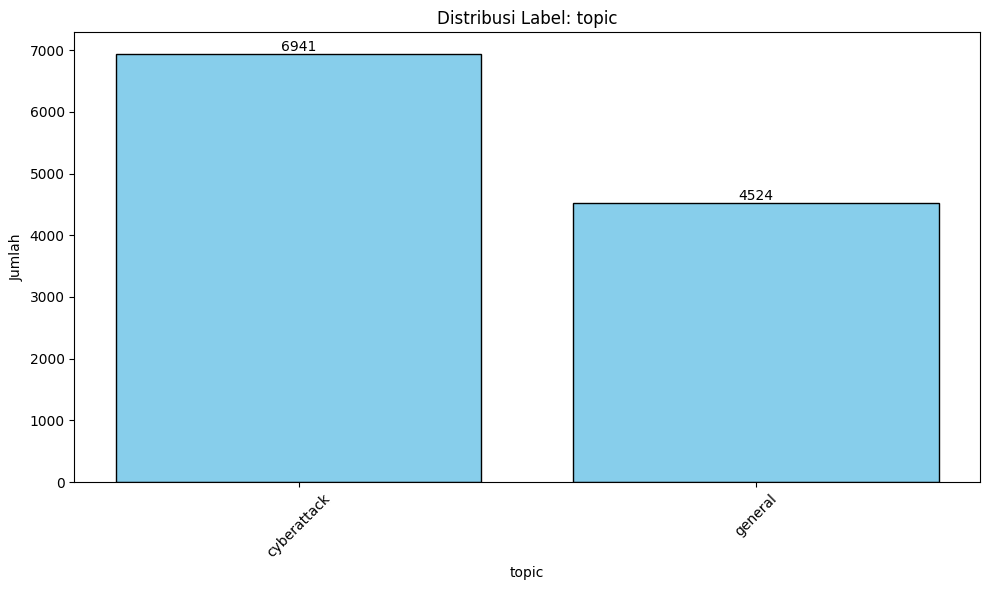

In [8]:
# Menampilkan distribusi label 'topic'
plot_label_distribution(raw_df, 'topic')

Rasio label ini tergolong cukup baik untuk banyak algoritma ML, dan tidak memerlukan penanganan imbalance khusus dalam banyak kasus, asalkan metrik evaluasi yang digunakan bukan akurasi saja.

In [9]:
# Menambahkan kolom baru berisi jumlah kata
raw_df['word_count'] = raw_df['content'].apply(lambda x: len(str(x).split()))

# Cek deskriptif dari kolom word_count
raw_df['word_count'].describe()

count    11465.000000
mean        11.071871
std          2.578915
min          3.000000
25%          9.000000
50%         11.000000
75%         13.000000
max         22.000000
Name: word_count, dtype: float64

Kolom word_count digunakan untuk melihat panjang kata dari baris pada kolom content. Panjang kata ini digunakan untuk menentukan apakah pada proses embedding nanti perlu dilakukan chunking terlebih dahulu. Namun, berdasarkan hasil deskriptif dari kolom word_count dapat terlihat bahwa tidak ada kata yang memiliki panjang hingga ratusan bahkan maksimal panjangnya hanya pada 22 kata. Jadi proses embedding nanti dapat dilakukan langsung tanpa perlu proses chunking.

## Data Preprocessing

Karena dataset ini berisi data berbasis teks, kita perlu mengubah teks tersebut ke dalam bentuk numerik agar dapat diproses oleh model machine learning. Untuk itu, kita akan melakukan embedding pada kolom content.

Sementara itu, untuk label kelas, kita hanya perlu mengubahnya ke format numerik menggunakan one-hot encoding. Metode ini dipilih karena tidak mengasumsikan adanya hubungan ordinal antar kelas, serta tidak menambah kompleksitas data secara signifikan, mengingat label hanya terdiri dari dua kelas.

Sebelum proses encoding dilakukan, kita akan menghapus kolom message_id dan juga akan mengganti nama kolom label menjadi "class" untuk mempermudah pembacaan dan analisis selama proses pengolahan data.

In [10]:
df = raw_df.copy()

In [11]:
df.drop(columns='message_id', inplace=True)

In [12]:
df.rename(columns={
    'topic': 'class'
}, inplace=True)

### Embedding Column *content*

In [13]:
def process_series_embedding(series, model, batch_size=32):
    texts = series.tolist()
    embeddings = model.encode(texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
    return embeddings

In [14]:
# Penggunaan
embedding_model = SentenceTransformer('all-mpnet-base-v2')
df["content_embed"] = list(process_series_embedding(df["content"], model=embedding_model))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/359 [00:00<?, ?it/s]

In [15]:
df["content_embed"].head()

0    [-0.014459944, -0.050637458, -0.0016422439, 0....
1    [0.033078596, -0.020331932, -0.02192105, 0.015...
2    [0.050302766, -0.00499145, -0.0010036777, 0.04...
3    [0.033929735, -0.033017762, -0.03469221, -0.00...
4    [0.013225952, -0.053387333, -0.03501518, 0.016...
Name: content_embed, dtype: object

Save dataframe hasil embedding

In [16]:
# Simpan DataFrame ke file pickle
df.to_pickle("df_cyberattack.pkl")

### Model Implementation

In [17]:
# Muat DataFrame dari file pickle
df_loaded = pd.read_pickle("df_cyberattack.pkl")

In [18]:
X = np.vstack(df_loaded['content_embed'])
y = df_loaded['class']

In [19]:
# Tentukan proporsi untuk train, validation, test secara manual
train_size = int(0.7 * len(X))  # 70% untuk training
val_size = int(0.15 * len(X))   # 15% untuk validation
test_size = len(X) - train_size - val_size  # Sisanya untuk test

# Pisahkan 15% untuk test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

# Pisahkan sisa 85% menjadi train dan validation set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, random_state=SEED)

In [20]:
# Fit OneHotEncoder untuk training data
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Mengonversi y_train ke NumPy array dan reshape
y_train_onehot = encoder.fit_transform(y_train.values.reshape(-1, 1))

# Transform validation dan test data dengan fitted encoder
y_val_onehot = encoder.transform(y_val.values.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.values.reshape(-1, 1))

In [21]:
# Definisikan model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED)
}

In [22]:
# Membuat pipeline (meskipun tidak diperlukan praproses di sini, pipeline memastikan skalabilitas)
pipelines = {name: Pipeline([(name, model)]) for name, model in models.items()}

In [23]:
# Simpan hasil evaluasi
results = {}

# Train & evaluasi pada validasi
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)  # Train dengan label asli
    y_val_pred = pipeline.predict(X_val)
    y_val_proba = pipeline.predict_proba(X_val)
    
    # Map prediksi kembali ke label asli
    y_val_true_labels = encoder.inverse_transform(y_val_onehot).ravel()
    y_val_pred_labels = y_val_pred  # Sudah dalam format label asli
    
    conf_matrix = confusion_matrix(y_val_true_labels, y_val_pred_labels, labels=encoder.categories_[0])
    loss_val = log_loss(y_val_onehot, y_val_proba)  # Gunakan one-hot encoded y untuk log_loss
    report = classification_report(y_val_true_labels, y_val_pred_labels, output_dict=True)
    
    results[name] = {
        'conf_matrix': conf_matrix,
        'log_loss': loss_val,
        'f1_macro': report['macro avg']['f1-score'],
        'classification_report': report
    }
    
    # Display hasil validasi
    print(f"\nValidation Results for {name}:")
    print(f"Log Loss: {loss_val:.4f}")
    print(f"F1-Macro: {report['macro avg']['f1-score']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val_true_labels, y_val_pred_labels))
    print("="*60)


Validation Results for Logistic Regression:
Log Loss: 0.0280
F1-Macro: 0.9963

Classification Report:
              precision    recall  f1-score   support

 cyberattack       1.00      1.00      1.00      1064
     general       1.00      0.99      1.00       655

    accuracy                           1.00      1719
   macro avg       1.00      1.00      1.00      1719
weighted avg       1.00      1.00      1.00      1719


Validation Results for K-Nearest Neighbors:
Log Loss: 0.0096
F1-Macro: 0.9969

Classification Report:
              precision    recall  f1-score   support

 cyberattack       1.00      1.00      1.00      1064
     general       1.00      0.99      1.00       655

    accuracy                           1.00      1719
   macro avg       1.00      1.00      1.00      1719
weighted avg       1.00      1.00      1.00      1719


Validation Results for Naive Bayes:
Log Loss: 0.1894
F1-Macro: 0.9877

Classification Report:
              precision    recall  f1-score  

### Analysis

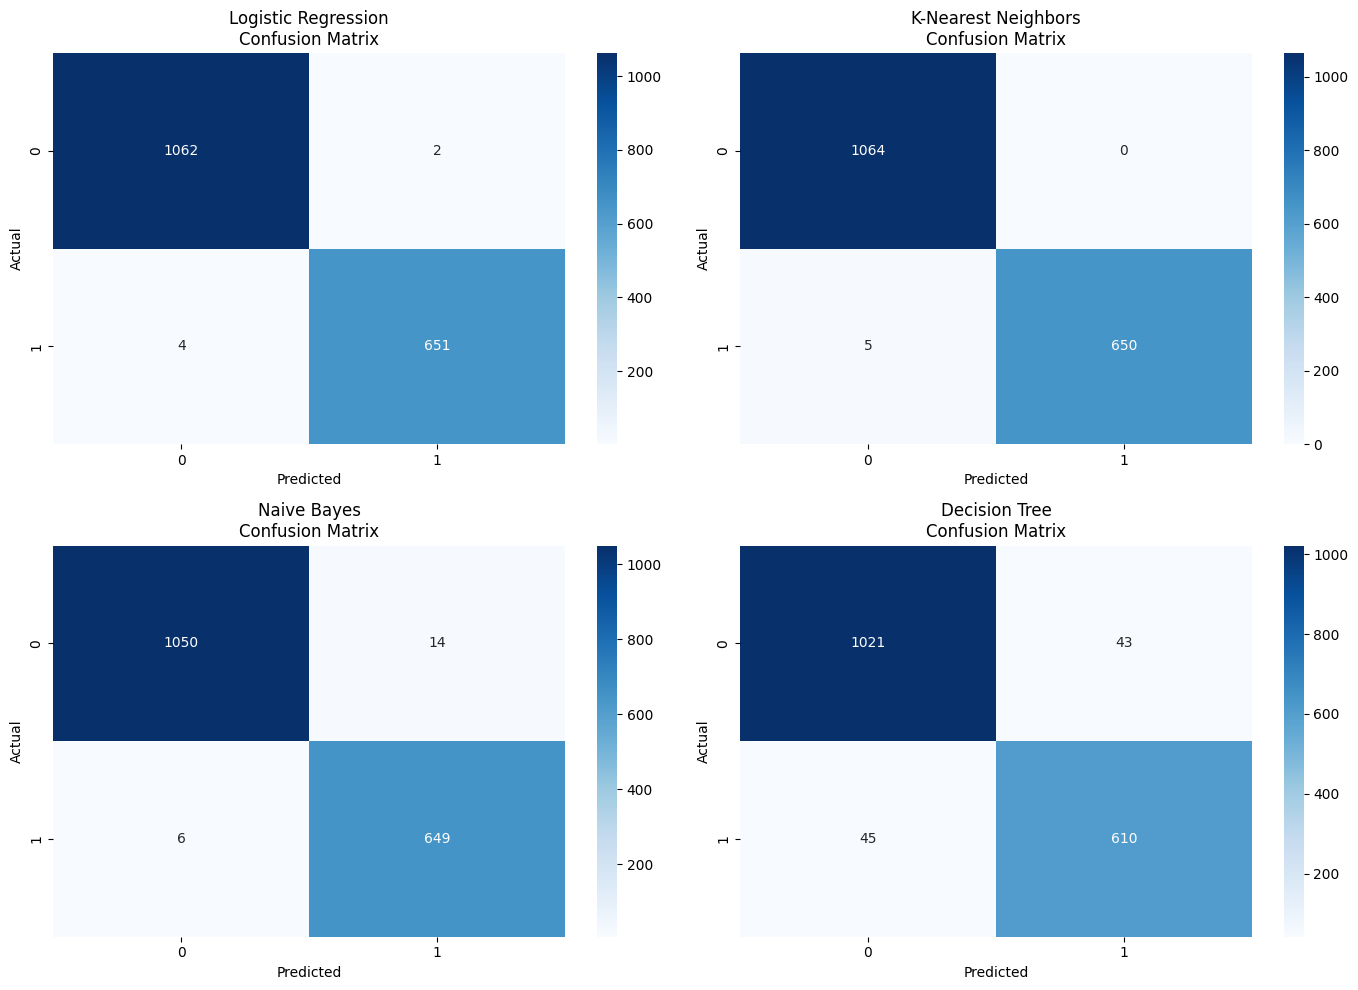

In [24]:
# Plot confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['conf_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()

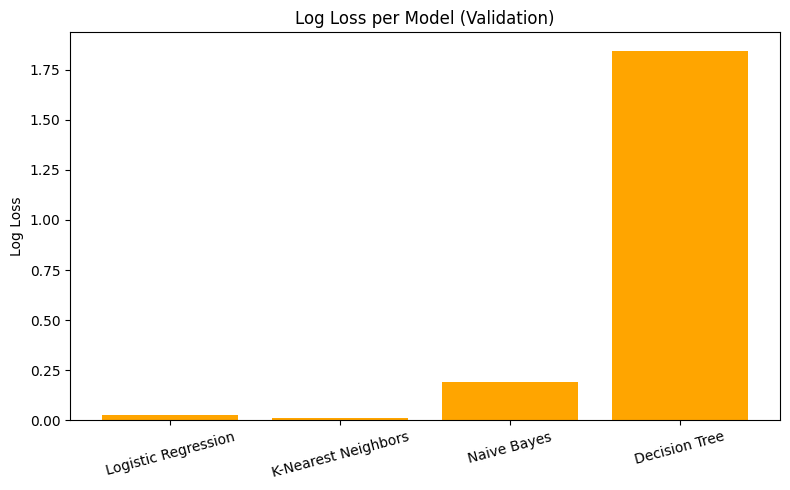

In [25]:
# Plot log loss
plt.figure(figsize=(8, 5))
loss_values = [res['log_loss'] for res in results.values()]
plt.bar(results.keys(), loss_values, color='orange')
plt.ylabel('Log Loss')
plt.title('Log Loss per Model (Validation)')
plt.xticks(rotation=15)
plt.tight_layout()

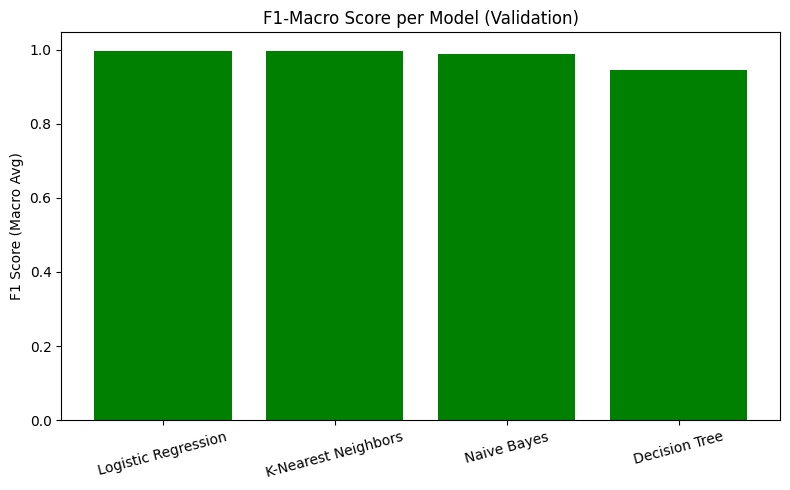

In [26]:
# Plot F1-Macro
plt.figure(figsize=(8, 5))
f1_scores = [res['f1_macro'] for res in results.values()]
plt.bar(results.keys(), f1_scores, color='green')
plt.ylabel('F1 Score (Macro Avg)')
plt.title('F1-Macro Score per Model (Validation)')
plt.xticks(rotation=15)
plt.tight_layout()

### Inference on Testing Set

In [27]:
# Inference on test set (best model based on validation F1-macro)
best_model_name = max(results, key=lambda x: results[x]['f1_macro'])
best_pipeline = pipelines[best_model_name]
y_test_pred = best_pipeline.predict(X_test)
y_test_proba = best_pipeline.predict_proba(X_test)

# Map test set predictions back to original labels
y_test_true_labels = encoder.inverse_transform(y_test_onehot).ravel()
y_test_pred_labels = y_test_pred  # Already in original label format

In [28]:
# Evaluate on test set
test_conf_matrix = confusion_matrix(y_test_true_labels, y_test_pred_labels, labels=encoder.categories_[0])
test_loss = log_loss(y_test_onehot, y_test_proba)  # Use one-hot encoded y for log_loss
test_report = classification_report(y_test_true_labels, y_test_pred_labels, output_dict=True)

# Display test set results
print(f"\nInference Results for Best Model ({best_model_name}) on Test Set:")
print(f"Log Loss: {test_loss:.4f}")
print(f"F1-Macro: {test_report['macro avg']['f1-score']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_true_labels, y_test_pred_labels))


Inference Results for Best Model (K-Nearest Neighbors) on Test Set:
Log Loss: 0.0272
F1-Macro: 0.9963

Classification Report:
              precision    recall  f1-score   support

 cyberattack       0.99      1.00      1.00      1053
     general       1.00      0.99      1.00       668

    accuracy                           1.00      1721
   macro avg       1.00      1.00      1.00      1721
weighted avg       1.00      1.00      1.00      1721



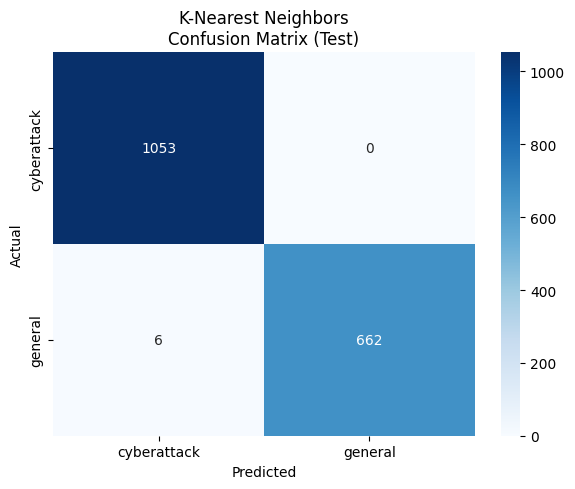

In [29]:
# Plot test set confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.title(f'{best_model_name}\nConfusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()